# House Price Prediction Using Machine Learning

## Project Objective

This project predicts house prices using different regression models.

Multiple machine learning algorithms are tested and compared
to find the best performing model for price prediction.

In [631]:
import pandas as pd
import seaborn as sns

In [632]:
df = pd.read_csv('Housing.csv')
df.shape

(545, 13)

In [633]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [634]:
df.isnull().sum() # no null values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [635]:
df.duplicated().sum() # no dupes

np.int64(0)

In [636]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


<Axes: xlabel='area', ylabel='price'>

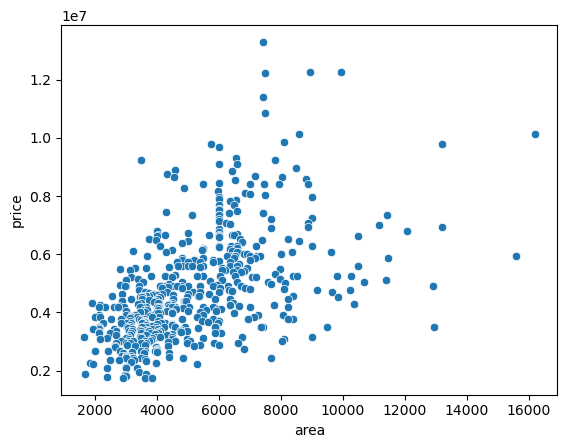

In [637]:
sns.scatterplot(x = df['area'], y = df['price'])

<Axes: xlabel='area', ylabel='price'>

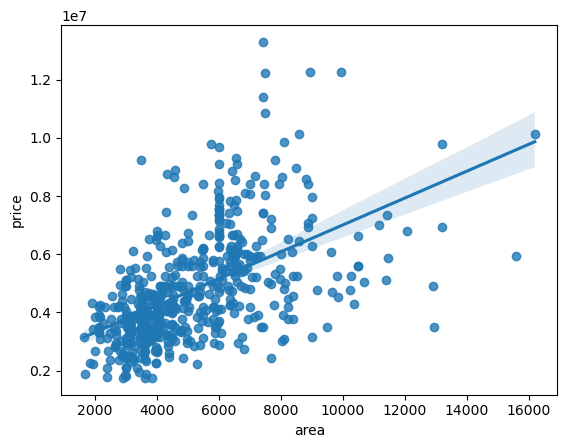

In [638]:
sns.regplot(x = df['area'], y = df['price'])
# On average, price increases as area increases.

In [639]:
# Observation:
# The scatter plot shows that house price generally increases with area.
# The regression line also shows a positive relationship between area and price.
# but, the spread of points indicates that other factors also influence price as well.

<Axes: xlabel='bedrooms', ylabel='price'>

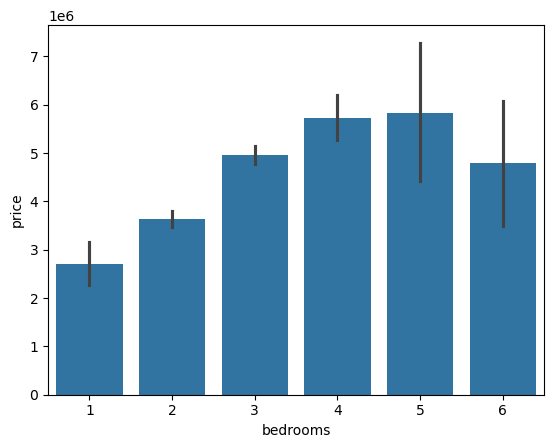

In [640]:
sns.barplot(x = df['bedrooms'], y = df['price'])

In [641]:
# Average house price generally increases with the number of bedrooms as is seen in the above barplot.
# Houses with 4 to 5 bedrooms are most expensive of the lot.
# also variation at 5, 6 bedroom shows bedroom count alone does not determine price

### Train–test split:

In [642]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [643]:
X = df[['area','bedrooms','bathrooms','stories','parking']] # features
X

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,1,0
542,3620,2,1,1,0
543,2910,3,1,1,0


In [644]:
y = df['price'] # target
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

#### Training Linear Regression model: 

In [645]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [646]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [647]:
# Making predictions
y_pred = model.predict(X_test)

In [648]:
X_test

,area,bedrooms,bathrooms,stories,parking
316,5900,4,2,2,1
77,6500,3,2,3,0
360,4040,2,1,1,0
90,5000,3,1,2,0
493,3960,3,1,1,0
...,...,...,...,...,...
15,6000,4,1,2,2
357,6930,4,1,2,1
39,6000,4,2,4,1
54,6000,3,2,2,1


In [649]:
y_pred

array([6178627.50326817, 6370140.85865473, 3283148.1570249 ,
       4226007.94816032, 3409685.55116741, 4262158.3499693 ,
       5493440.53152357, 5559897.74293016, 3373715.42245305,
       3020513.18649699, 9519985.01490602, 3250408.25967961,
       3184310.73107686, 3639160.7315938 , 3907874.98339005,
       6174323.64572264, 3148160.32926787, 4872535.73454622,
       4826205.69113307, 3888527.39095668, 5222386.81260559,
       4294589.38035851, 3162381.17719464, 4193028.43115341,
       5747707.28367817, 7619041.42465273, 2989724.54874164,
       4794005.74968623, 7434038.64867549, 3457027.28535552,
       5102872.70577387, 3982998.90101381, 6215707.38061091,
       4724828.08224186, 4307759.63367012, 5625853.70972471,
       4791990.70630181, 3815116.83871033, 3261429.41224535,
       4879463.83866908, 5326652.37523625, 3156512.70502897,
       6345431.50216772, 4316575.21358846, 4120177.60802241,
       4190668.52130486, 6710808.14327267, 4603723.42489655,
       4521704.65093635,

### Evaluating model performance

In [650]:
from sklearn.metrics import mean_squared_error, r2_score

In [651]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 2292721545725.3613
RMSE: 1514173.552049223
R² Score: 0.5464062355495873


In [652]:
# Observation:
# The model achieved an R2 score of around 0.55, which indicates moderate performance.
# Also model was trained on only Numerical columns, Categorical were skipped. 

### Converting categorical variables into numeric format using one-hot encoding


In [653]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [654]:
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,False,False,False,False,False,False,False,False


In [655]:
df_encoded = df_encoded.astype(int) # converting to numeric since model undestands that
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


### Feature Engineering Features: 
#### To Increase Model Accuracy. 

In [656]:
df_encoded["area_per_room"] = df_encoded["area"] / df_encoded["bedrooms"]
df_encoded["bath_per_room"] = df_encoded["bathrooms"] / df_encoded["bedrooms"]
df_encoded['total_rooms'] = df_encoded['bedrooms'] + df_encoded['bathrooms']

In [657]:
X = df_encoded.drop(columns = "price") # features
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_per_room,bath_per_room,total_rooms
0,7420,4,2,3,2,1,0,0,0,1,1,0,0,1855.000000,0.500000,6
1,8960,4,4,4,3,1,0,0,0,1,0,0,0,2240.000000,1.000000,8
2,9960,3,2,2,2,1,0,1,0,0,1,1,0,3320.000000,0.666667,5
3,7500,4,2,2,3,1,0,1,0,1,1,0,0,1875.000000,0.500000,6
4,7420,4,1,2,2,1,1,1,0,1,0,0,0,1855.000000,0.250000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0,0,1,1500.000000,0.500000,3
541,2400,3,1,1,0,0,0,0,0,0,0,1,0,800.000000,0.333333,4
542,3620,2,1,1,0,1,0,0,0,0,0,0,1,1810.000000,0.500000,3
543,2910,3,1,1,0,0,0,0,0,0,0,0,0,970.000000,0.333333,4


In [658]:
y = df_encoded['price'] # target
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [659]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [660]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [661]:
y_pred = model.predict(X_test)

In [662]:
X_test

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_per_room,bath_per_room,total_rooms
316,5900,4,2,2,1,0,0,1,0,0,0,0,1,1475.000000,0.500000,6
77,6500,3,2,3,0,1,0,0,0,1,1,0,0,2166.666667,0.666667,5
360,4040,2,1,1,0,1,0,0,0,0,0,1,0,2020.000000,0.500000,3
90,5000,3,1,2,0,1,0,0,0,1,0,1,0,1666.666667,0.333333,4
493,3960,3,1,1,0,1,0,0,0,0,0,0,0,1320.000000,0.333333,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,2,1,0,1,0,0,0,1,0,1500.000000,0.250000,5
357,6930,4,1,2,1,0,0,0,0,0,0,0,0,1732.500000,0.250000,5
39,6000,4,2,4,1,1,0,0,0,1,0,1,0,1500.000000,0.500000,6
54,6000,3,2,2,1,1,1,0,0,1,0,1,0,2000.000000,0.666667,5


In [663]:
y_pred

array([5177947.82500956, 7224827.34894804, 3117009.09583014,
       4652035.52613759, 3358495.91357771, 3587553.64083661,
       5682144.44214121, 6346097.52305649, 2761426.01219295,
       2697919.34518573, 9682133.91090305, 2811479.01317657,
       3203753.02206143, 3431088.19272325, 3714350.08346662,
       5250214.21495774, 3108052.70450868, 4827267.15121812,
       4383320.60537245, 3503084.33852217, 5769535.47347842,
       5917311.83367965, 2755340.52125452, 4733451.55600959,
       5289898.51951717, 7548235.75119198, 3258118.40947047,
       5205965.36268194, 8185956.60071882, 3447098.87323294,
       6483200.85023408, 3347350.73608362, 6719950.20787245,
       4240133.12161371, 3500249.82191251, 5849077.75892179,
       4829749.32609638, 4271827.81562215, 3252155.31370424,
       4553384.67604299, 4616144.06960173, 3547225.08203873,
       7205819.31316409, 4030678.72645426, 3650817.21200127,
       4213690.26928223, 6745190.75324119, 3972363.8741324 ,
       3622237.02282983,

In [664]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 1749064548883.748
RMSE: 1322522.0409822091
R² Score: 0.6539637469390376


### Observation:
#### After encoding categorical features, model performance improved.
#### R2 score increased and RMSE decreased compared to the basic model.
#### Additional features added in Feature Engineering also help in better R² Score & price prediction.

### # Training Random Forest Regressor to compare with Linear Regression:

In [666]:
from sklearn.ensemble import RandomForestRegressor

In [667]:
# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,          # full depth
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 1403652.3738634659
Random Forest R²: 0.6102062310694968


In [668]:
rf_model.score(X_test,y_test) ## Returns R²

0.6102062310694968

In [669]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

y_pred_rf = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 1970239986652.5427
RMSE: 1403652.3738634659
R2 Score: 0.6102062310694968


### Observation:
#### Random Forest did not outperform Linear Regression in this case.
#### The R2 score is slightly lower and RMSE is slightly higher.
#### This suggests that the relationship in the data is mostly linear.


### # Training Ridge Regression

In [670]:
from sklearn.linear_model import Ridge

In [671]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [672]:
# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)  

In [673]:
# Train the model
ridge_model.fit(X_train, y_train)

Ridge()

In [674]:
# Predict on test set
y_pred = ridge_model.predict(X_test)

In [675]:
import numpy as np

In [676]:
# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge RMSE:", rmse)
print("Ridge R²:", r2)

Ridge RMSE: 1322708.6646629109
Ridge R²: 0.653866080339004


### Model Comparison Summary:
#### Linear Regression and Ridge Regression performed best.
#### Random Forest gave slightly worse results in this case.
#### This suggests that the relationship between features and price is mostly linear.

<Axes: xlabel='area', ylabel='Count'>

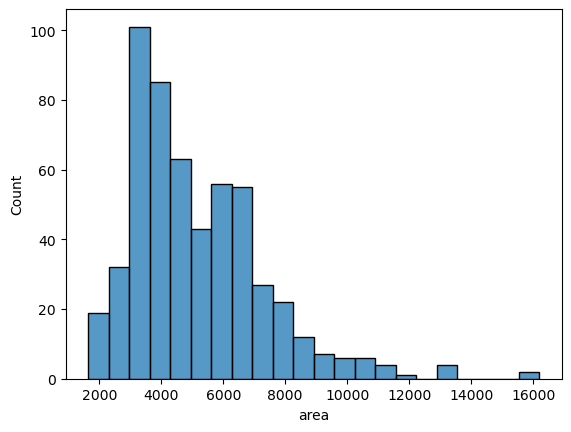

In [677]:
sns.histplot(df['area'])
# The distribution is slightly right-skewed.

<Axes: xlabel='price', ylabel='Count'>

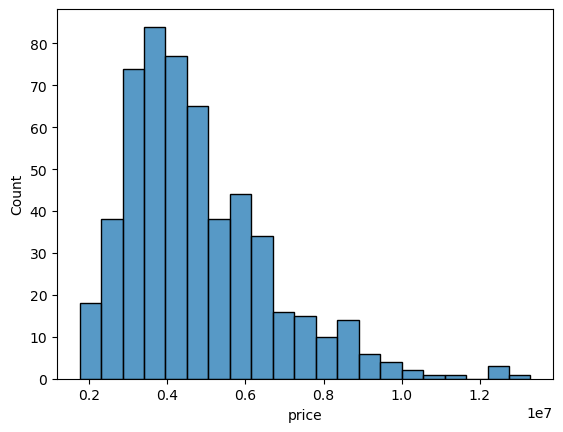

In [678]:
sns.histplot(df['price'])
# The distribution is slightly right-skewed too.

### Feature Engineering & Retraining the model with Newly Added Features(log Features):

In [679]:
import numpy as np

In [680]:
# log1p(x) computes:
# log1p(x)=log(1+x)

# Why 1 + x?

# Avoids issues if x = 0 (since log(0) is undefined)

# Ensures even very small numbers work

# large numbers get compressed, and small numbers stay small.


# Why we do this:

# Compresses outliers (very large areas) → reduces their effect on models.

# Makes skewed distributions more symmetric, closer to normal.

# Helps linear models see relationships more clearly (linearizes exponential relationships).

# Safe for zero values because of log1p.

In [681]:
# Add log-transformed column('area' & price):-
df_encoded['log_area'] = np.log1p(df_encoded['area'])
df_encoded['log_price'] = np.log1p(df_encoded['price'])

In [682]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_per_room,bath_per_room,total_rooms,log_area,log_price
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,1855.0,0.500000,6,8.912069,16.403275
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,2240.0,1.000000,8,9.100637,16.321037
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,3320.0,0.666667,5,9.206433,16.321037
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,1875.0,0.500000,6,8.922792,16.318175
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,1855.0,0.250000,5,8.912069,16.250001


<Axes: xlabel='log_area', ylabel='Count'>

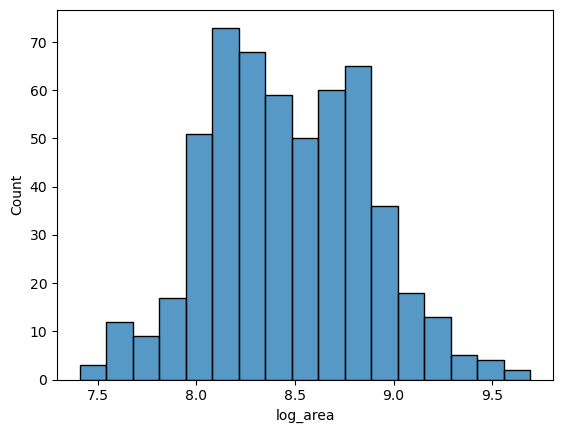

In [684]:
sns.histplot(df_encoded['log_area'])

<Axes: xlabel='log_price', ylabel='Count'>

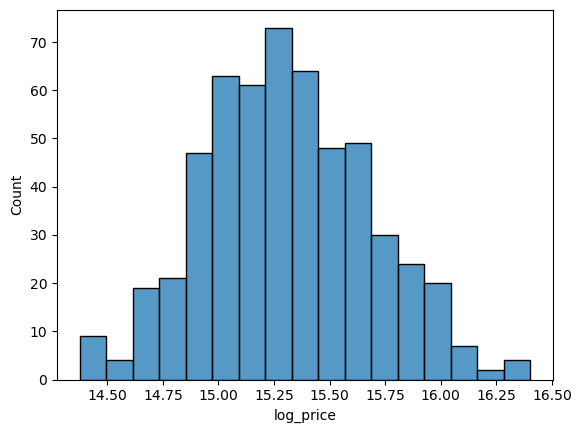

In [686]:
sns.histplot(df_encoded['log_price'])

## Conclusion , Skewness Decreased

In [687]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_per_room,bath_per_room,total_rooms,log_area,log_price
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,1855.0,0.500000,6,8.912069,16.403275
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,2240.0,1.000000,8,9.100637,16.321037
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,3320.0,0.666667,5,9.206433,16.321037
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,1875.0,0.500000,6,8.922792,16.318175
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,1855.0,0.250000,5,8.912069,16.250001


In [701]:
X = df_encoded.drop(columns = ["price","log_price"]) # features
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_per_room,bath_per_room,total_rooms,log_area
0,7420,4,2,3,2,1,0,0,0,1,1,0,0,1855.000000,0.500000,6,8.912069
1,8960,4,4,4,3,1,0,0,0,1,0,0,0,2240.000000,1.000000,8,9.100637
2,9960,3,2,2,2,1,0,1,0,0,1,1,0,3320.000000,0.666667,5,9.206433
3,7500,4,2,2,3,1,0,1,0,1,1,0,0,1875.000000,0.500000,6,8.922792
4,7420,4,1,2,2,1,1,1,0,1,0,0,0,1855.000000,0.250000,5,8.912069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0,0,1,1500.000000,0.500000,3,8.006701
541,2400,3,1,1,0,0,0,0,0,0,0,1,0,800.000000,0.333333,4,7.783641
542,3620,2,1,1,0,1,0,0,0,0,0,0,1,1810.000000,0.500000,3,8.194506
543,2910,3,1,1,0,0,0,0,0,0,0,0,0,970.000000,0.333333,4,7.976252


In [702]:
y = df_encoded['log_price'] # target
y

0      16.403275
1      16.321037
2      16.321037
3      16.318175
4      16.250001
         ...    
540    14.414348
541    14.384879
542    14.375127
543    14.375127
544    14.375127
Name: log_price, Length: 545, dtype: float64

#### Ridge(II):

In [703]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [704]:
# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0) 

In [705]:
# Train the model
ridge_model.fit(X_train, y_train)

Ridge()

In [706]:
# Predict on test set
y_pred = ridge_model.predict(X_test)

In [708]:
# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge RMSE:", rmse) # log Value.
print("Ridge R²:", r2)

Ridge RMSE: 0.24104284488758979
Ridge R²: 0.6650634044019947


#### LinearRegression(II): 

In [709]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [710]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [711]:
y_pred = model.predict(X_test)

In [712]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 0.06273431591838478
RMSE: 0.25046819342660015
R² Score: 0.6751009506128323


#### Random Forest(II):

In [713]:
# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,          # full depth
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)



In [714]:
# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.2651735998341603
Random Forest R²: 0.6358302711459292


#### Gradient Boosting Regressor: (better for Nonlinear patterns)

In [724]:
from sklearn.ensemble import GradientBoostingRegressor # Better for Realistic Price Estimation.

gbr = GradientBoostingRegressor(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 4,
    random_state = 42
)

gbr.fit(X_train, y_train)

pred = gbr.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))


R2: 0.6431324555628101
RMSE: 0.26250156034468664


### Final Model Comparison:
#### Linear Regression: R2 ~ 0.653 , 0.675 
#### Ridge Regression: R2 ~ 0.653 , 0.665
#### Random Forest: R2 ~ 0.616 , 0.635
#### Gradient Boosting: R2 ~ 0.643

##### Linear Regression(V2) best , But Gradient Boosting does give better price prediction on the app.

In [726]:
#import joblib


#joblib.dump(model, "house_price_model.pkl")
#joblib.dump(X.columns.tolist(), "model_features.pkl") 
#already tried linear model on streamlit, price predicition diff was too big.


In [727]:
import joblib


joblib.dump(gbr, "house_price_model.pkl")
joblib.dump(X.columns.tolist(), "model_features.pkl") 

['model_features.pkl']